<div style="background-color:#EAEAEA;padding:20px;border-left:5px solid #6C757D;border-radius:6px;">
<table style="width:100%; border:none;"><tr style="border:none;">
<td style="border:none; vertical-align:top;">
<h1 style="font-size:32px; margin-top:0;">Master's Thesis</h1>
<hr style="margin:16px 0 22px 0;">
<p style="font-size:22px; line-height:1.5; margin:0;"><strong>Master's Degree in Advanced Physics</strong> - <strong>Universitat de Valencia</strong></p>
<p style="font-size:17px; margin-top:28px; margin-bottom:6px;">This notebook is part of the <strong>Master's Thesis (MSc Dissertation)</strong>:</p>
<div style="font-size:25px;font-weight:700;line-height:1.3;margin-top:14px;margin-bottom:26px;">Fast Simulation of Neutrino Oscillations in Matter</div>
<p style="font-size:14px; line-height:1.55;"><strong>Author</strong><br>Juan Ramon Diaz Santos - <a href="mailto:diazjuan@alumni.uv.es">diazjuan@alumni.uv.es</a></p>
<p style="font-size:14px; line-height:1.55;"><strong>Supervisors</strong><br>Roberto Ruiz de Austri Bazan - <a href="mailto:rruiz@ific.uv.es">rruiz@ific.uv.es</a><br>Michele Lucente - <a href="mailto:michele.lucente@unibo.it">michele.lucente@unibo.it</a></p>
<p style="font-size:14px; line-height:1.55; margin-bottom:0;"><strong>Date</strong><br>September 2026</p></td>
<td style="border:none;width:230px;padding-left:25px;text-align:right;vertical-align:top;"><img src="../../logo_uv.png" alt="Universitat de Valencia" style="width:200px; margin-top:5px;"></td>
</tr></table></div>

# Intrinsic Validation 1 - Standard Model Propagation
---
This notebook contains the physical propagation scenarios for the three-flavour Standard Model. Numerical propagation is the discretized reference and the first-order perturbative or adiabatic path is the tested implementation. Numerical-method convergence, perturbative options and `RuntimeContext` studies have been moved to Intrinsic Validations 4, 5 and 6.

## Table of Contents

| # | Section |
|---|---|
| [0](#0.-Theoretical-Framework) | **Theoretical Framework** |
| [1](#1.-Libraries) | **Libraries** |
| [2](#2.-Paths-and-Configuration) | **Paths and Configuration** |
| [3](#3.-Solar-Propagation) | **Solar Propagation** |
| [4](#4.-Pure-Flavour-States-Through-Earth) | **Pure Flavour States Through Earth** |
| [5](#5.-Solar-Neutrinos-to-the-Detector) | **Solar Neutrinos to the Detector** |
| [6](#6.-Atmospheric-Propagation) | **Atmospheric Propagation** |
| [7](#7.-Summary) | **Summary** |


## 0. Theoretical Framework
---
### 0.1 Evolution in matter

A flavour state obeys $i\,d\psi/dx=H_f(x)\psi$. In the three-flavour Standard Model, after subtracting an irrelevant identity contribution,

$$H_f(x)=\frac{1}{2E}U\,\mathrm{diag}(0,\Delta m^2_{21},\Delta m^2_{31})U^\dagger+V_{\rm CC}(x)P_e,\qquad P_e=\mathrm{diag}(1,0,0),\quad V_{\rm CC}=\sqrt{2}G_Fn_e(x).$$

The matter term is the Wolfenstein charged-current potential [1]. The exact evolution operator is $S(x_2,x_1)=\mathcal{T}\exp[-i\int_{x_1}^{x_2}H_f(x)dx]$.

### 0.2 First-order perturbative method

Within every crossed segment, TPeanuts writes $n_e(x)=\bar n_e+\delta n_e(x)$ and constructs

$$H_f(x)=H_0+H_1(x),\qquad H_0=H_{\rm kin}+\bar V_{\rm CC}P_e,\qquad H_1(x)=\delta V_{\rm CC}(x)P_e=\sqrt{2}G_F\,\delta n_e(x)P_e.$$

First, $H_{\rm kin}$ is built from the PMNS matrix, mass-squared differences, energy and evolution scale. The profile supplies $\bar V_{\rm CC}$, which is added to form $H_0$. The code diagonalizes the traceless part of $H_0$, obtaining eigenvalues $\lambda_a$ and spectral projectors $M_a$. The constant-density contribution is exact,

$$S_0(L)=e^{-iH_0L}=\sum_a e^{-i(\lambda_a+\mathrm{Tr}H_0/N)L}M_a.$$

The residual density contributes the first Dyson term [2],

$$S_1(L)=-i\int_0^L S_0(L-x)H_1(x)S_0(x)\,dx=-i\sum_{a,b}I_{ab}M_aP_eM_b,$$

where $I_{ab}$ contains the matter-potential factor and the analytical oscillatory integral of $\delta n_e(x)e^{-i(\lambda_b-\lambda_a)x}$. The segment operator is $S\simeq S_0+S_1$, and segment operators are multiplied in propagation order. Earth uses layered `even_power` profiles; atmosphere propagation uses local polynomial fits. First-order truncation need not be exactly unitary; its dedicated analysis is performed in Intrinsic Validation 5.

### 0.3 Segmented numerical method

The numerical branch divides the path into $N_{\rm step}$ intervals. With midpoint sampling,

$$H_j=H_f(x_{j+1/2}),\qquad S_j=\exp(-iH_j\Delta x_j),\qquad S_{\rm num}=S_{N-1}S_{N-2}\cdots S_1S_0.$$

Every factor is exactly unitary for a Hermitian sampled Hamiltonian. The approximation is the piecewise-constant replacement of the continuous profile; the ordered product converges to the path-ordered exponential when $\max_j\Delta x_j\to0$. Constant-density layers and their ordered products are a standard treatment of varying-density neutrino propagation [3]. This method does not expand in $\delta n_e$ and does not support `reunitarize=True`.

### 0.4 Coherent and incoherent probabilities

For coherent flavour amplitudes, propagation precedes the modulus square [4]:

$$\psi^{\rm out}=S\psi^{\rm in},\qquad P_\beta^{\rm coh}=|\psi_\beta^{\rm out}|^2=\left|\sum_\alpha S_{\beta\alpha}\psi_\alpha^{\rm in}\right|^2.$$

For incoherent mass-eigenstate weights $w_i$, probabilities are summed instead:

$$P_\beta^{\rm inc}=\sum_iw_i|A_{\beta i}|^2,\qquad A=SU,\qquad \sum_iw_i=1.$$

Pure flavour and atmospheric states use coherent propagation (`massbasis=False`). Solar neutrinos reach Earth as incoherent mass weights (`massbasis=True`). Atmosphere-to-detector amplitudes are composed as $S_{\rm total}=S_{\rm Earth}S_{\rm atm}$ before squaring.

### 0.5 Solar-surface propagation methods

`solar_probability_mass` returns incoherent vacuum mass-eigenstate weights at the solar surface after averaging over the source-production distribution. It provides three complementary methods:

1. **`numerical`.** A production state $|\nu_e\rangle$ is propagated coherently through the piecewise-constant solar profile and projected onto the vacuum mass basis at the surface:

$$P_i^{\odot,\mathrm{num}}(E)=\int dr\,f(r)\left|\langle\nu_i|S(R_\odot,r;E)|\nu_e\rangle\right|^2.$$

   It imposes no adiabatic approximation; its numerical accuracy depends on radial discretization.

2. **`adiabatic_approximated` (default).** The closed-form effective matter angles $\theta_{12}^M$ and $\theta_{13}^M$ approximate the local three-flavour eigenvectors through a sequential two-level reduction. Without Landau-Zener transitions, the local weights are

$$w_1^M=c_{13,M}^2c_{12,M}^2,\qquad w_2^M=c_{13,M}^2s_{12,M}^2,\qquad w_3^M=s_{13,M}^2,$$

   and $P_i^{\odot,\mathrm{ad,approx}}(E)=\int dr\,f(r)w_i^M(r,E)$. This fast closed form is restricted to the plain three-flavour Standard Model, although it may optionally include the local two-level Landau-Zener correction.

3. **`adiabatic_exact`.** The complete flavour-basis Hamiltonian is diagonalized independently at every $(r,E)$. If $|\nu_i^M(r,E)\rangle$ is the instantaneous eigenvector continuously associated with vacuum state $|\nu_i\rangle$,

$$P_i^{\odot,\mathrm{ad,exact}}(E)=\int dr\,f(r)\left|\langle\nu_i^M(r,E)|\nu_e\rangle\right|^2.$$

   This remains adiabatic, but avoids the sequential two-level reduction and supports the full Hamiltonian, including NSI and the $3+1$ extension. It has no separate Landau-Zener option.

**NOTES**
 - The two adiabatic methods neglect transitions between instantaneous eigenstates.
 - The exact qualifier in `adiabatic_exact` refers to pointwise diagonalization of the complete Hamiltonian, not to exact radial evolution.
 - The `numerical` method is used as reference in Section 3.

### 0.6 Validation observables

The numerical result is the reference and the perturbative result is tested. We report $|\Delta P|=|P_{\rm tested}-P_{\rm reference}|$ and $|\Delta P|/|P_{\rm reference}|$ only where $|P_{\rm reference}|\geq10^{-5}$. Smaller reference probabilities are excluded from relative summaries, while normalization is checked independently.

**Reading max_rel**: 
- Relative error is a ratio, so it is intrinsically unstable near a probability zero-crossing or a strongly suppressed oscillation channel: if both compared probabilities are genuinely tiny (e.g. ) at one particular grid point, a perfectly ordinary absolute mismatch there divides out to an relative error, even though the two methods agree everywhere else to high precision.
- This is a well-known artefact of relative-error metrics, not evidence of a propagation bug -- always cross-check a large max_rel against max_abs and against median_rel (which stays tiny whenever the large max_rel is an isolated near-zero-crossing point rather than a systematic effect).

### 0.7 Common simulation configuration

| Medium/Module | Attribute | Value |
|---|---|---|
| Core | Physics model | Standard Model, three flavours |
| Core | Oscillation preset / ordering | `_SM_NUFIT52_NO` / normal ordering [5] |
| Core | Legacy precision | `False` |
| Solar | Evolution methods / Landau-Zener | `numerical`, `adiabatic_approximated`, `adiabatic_exact` / disabled |
| Solar | Density / spectrum provider | `zenodo` / `legacy` |
| Earth | Perturbative / density model | `even_power` / PREM provider |
| Earth | Numerical method | Midpoint, 400 steps in Sections 4-6 |
| Earth | Detector depth / reunitarize | $1000\,\mathrm{m}$ / `False` in basic cases |
| Atmosphere | Density model | Exponential, matter enabled |
| Atmosphere | Perturbative / numerical | 6 cubic segments / 600 midpoint steps |
| Config | Basic energy and angular grids | 90 points per axis |
| Config | Device / dtype | Runtime-resolved values printed below |
| Config | Relative-error threshold | $10^{-5}$ |

**References**

- [1] [1] L. Wolfenstein, *Neutrino oscillations in matter*, Phys. Rev. D **17**, 2369 (1978).
- [2] [2] E. K. Akhmedov, M. Maltoni and A. Yu. Smirnov, *1-3 leptonic mixing and the neutrino oscillograms of the Earth*, JHEP **05**, 077 (2007), arXiv:hep-ph/0612285.
- [3] [3] P. M. Fishbane and P. Kaus, *Neutrino oscillations in matter of varying density*, Phys. Rev. D **64**, 113010 (2001), arXiv:hep-ph/0101013.
- [4] [4] C. Giunti and C. W. Kim, *Fundamentals of Neutrino Physics and Astrophysics*, Oxford University Press (2007).
- [5] [5] I. Esteban et al., *The fate of hints: updated global analysis of three-flavor neutrino oscillations*, JHEP **09**, 178 (2020), arXiv:2007.14792; NuFIT 5.2 release (2022).


## 1. Libraries

In [1]:
from __future__ import annotations
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from tpeanuts.notebooks.notebookConfig import load_notebook_config
from tpeanuts.notebooks.notebooks_helper import (ABSOLUTE_THRESHOLD, FLAVOUR_LABELS, save_and_show, to_numpy, validation_metrics, validation_heatmap, validation_comparison_grid, validation_summary_plot)
from tpeanuts.config.propagation import PropagationConfig
from tpeanuts.medium.earth.profile import EarthParameters, EarthProfile
from tpeanuts.medium.earth.probability import earth_probability_state
from tpeanuts.medium.solar.profile import SolarProfile
from tpeanuts.medium.solar.probability import solar_probability_mass
from tpeanuts.medium.atmosphere.profile import AtmosphereParameters
from tpeanuts.medium.atmosphere.evolutor import atmosphere_evolutor
from tpeanuts.medium.atmosphere.probability import atmosphere_probability_transition
from tpeanuts.util.context import RuntimeContext

## 2. Paths and Configuration

### 2.1 Paths

`load_notebook_config()` resolves the package directory and applies the common plotting, Torch and NumPy configuration. Following the notebook-relative convention, generated figures and tables are saved under `validation/intrinsic/`.

**Expected results:** the package and output directories exist, and the runtime device and dtype match the shared notebook configuration.


In [2]:
config = load_notebook_config()
DEVICE, DTYPE = config.device, config.dtype
context = RuntimeContext.resolve(DEVICE, DTYPE)
OUTPUT_DIR = config.output_dir('validation', 'intrinsic')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'Package dir : {config.package_dir}')
print(f'Output dir  : {OUTPUT_DIR}')
print(f'Device      : {context.device}   dtype: {context.dtype}')

Package dir : G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts
Output dir  : v:\output\validation\intrinsic
Device      : cuda:0   dtype: torch.float64


### 2.2 Configuration

The runtime-resolved configuration below is the single source of truth for all calculations. It instantiates the NuFIT 5.2 normal-ordering preset, PREM-derived Earth inputs, the default solar providers, an exponential atmosphere and the common numerical grids described in Section 0.7.

**Expected results:** all profiles load successfully, the table reports the actual device and dtype, and every probability tensor uses that same runtime context.

In [3]:
CDTYPE = torch.complex128 if context.dtype == torch.float64 else torch.complex64
oscillation = PropagationConfig.oscillation_parameters_from_preset('_SM_NUFIT52_NO', context=context, antinu=False)
earth = EarthProfile(params=EarthParameters(density_provider='prem', profile_perturbative_name='even_power', profile_perturbative_kwargs={'density_file': str(config.earth_density_file), 'tabulated_density': False}), context=context)
solar = SolarProfile.default(context=context)
atmosphere = AtmosphereParameters(atmosphere_density_source='exponential', nsteps=600, matter=True, perturbative_segments=6, perturbative_degree=3)
DEPTH_M, N_EARTH_STEPS = 1000.0, 400
LEGACY_PRECISION = False
REFERENCE_LABEL, TESTED_LABEL = 'numerical', 'perturbative'
BASIS = torch.eye(3, device=context.device, dtype=CDTYPE)
configuration_rows = [('Core','Physics model','SM (three flavours)'),('Core','Oscillation preset',oscillation.preset_name),('Core','Ordering',oscillation.ordering),('Core','Legacy precision',LEGACY_PRECISION),('Solar','Evolution methods','numerical / adiabatic_approximated / adiabatic_exact'),('Solar','Landau-Zener',False),('Solar','Density provider','zenodo'),('Solar','Spectrum provider','legacy'),('Earth','Perturbative model',earth.params.profile_perturbative_name),('Earth','Density provider',earth.params.density_provider),('Earth','Numerical steps',N_EARTH_STEPS),('Earth','Detector depth [m]',DEPTH_M),('Earth','Reunitarize basic cases',False),('Atmosphere','Density model',atmosphere.atmosphere_density_source),('Atmosphere','Perturbative fit',f'{atmosphere.perturbative_segments} x degree {atmosphere.perturbative_degree}'),('Atmosphere','Numerical steps',atmosphere.nsteps),('Config','Grid points per basic axis',90),('Config','Device',str(context.device)),('Config','Real dtype',str(context.dtype)),('Config','Relative-error threshold',ABSOLUTE_THRESHOLD)]
display(pd.DataFrame(configuration_rows, columns=['Medium/Module','Attribute','Value']))

,Medium/Module,Attribute,Value
0,Core,Physics model,SM (three flavours)
1,Core,Oscillation preset,_SM_NUFIT52_NO
2,Core,Ordering,NO
3,Core,Legacy precision,False
4,Solar,Evolution methods,numerical / adiabatic_approximated / adiabatic...
5,Solar,Landau-Zener,False
6,Solar,Density provider,zenodo
7,Solar,Spectrum provider,legacy
8,Earth,Perturbative model,even_power
9,Earth,Density provider,prem


### 2.3 Shared validation helpers

The reusable validation helpers compute absolute, thresholded-relative and normalization errors, and draw the common heatmaps and probability/error grids. Every physical scenario is self-contained after Sections 1 and 2 and writes its figures into `OUTPUT_DIR`.


In [4]:
summaries = []
ABSOLUTE_THRESHOLD = 1e-3
def record_metrics(case, reference, tested):
    row, absolute, relative = validation_metrics(case, reference, tested, reference_label=REFERENCE_LABEL, tested_label=TESTED_LABEL, absolute_threshold=ABSOLUTE_THRESHOLD)
    summaries.append(row)
    display(pd.DataFrame([row]).set_index('case').style.format({c: '{:.3e}' for c, value in row.items() if isinstance(value, float)}))
    return absolute, relative


## 3. Solar Propagation

This comparison evaluates the mass-eigenstate probabilities at the solar surface for $^8$B neutrinos using all three methods exposed by `solar_probability_mass`:

- `numerical` coherently propagates the production state through the discretized solar density profile and projects the final state onto the vacuum mass basis; it is used as the reference.
- `adiabatic_approximated` uses the closed-form effective angles $\theta_{12}^M$ and $\theta_{13}^M$ and is the default fast Standard-Model approximation.
- `adiabatic_exact` diagonalizes the complete local flavour-basis Hamiltonian at every production point, while still assuming adiabatic following.

After averaging over the normalized radial production distribution $f_{8B}(r)$, either adiabatic construction has the generic form

$$
P_i^{\odot,\mathrm{ad}}(E)=\int_0^{R_\odot}dr\,f_{8B}(r)\,|U^m_{ei}(r,E)|^2,\qquad \int_0^{R_\odot}dr\,f_{8B}(r)=1,
$$

Here $U^m(r,E)$ is approximated through sequential effective angles by `adiabatic_approximated` and obtained by full pointwise diagonalization by `adiabatic_exact`. The latter is exact only with respect to the local Hamiltonian diagonalization; both methods still impose adiabatic evolution.

- With Landau-Zener transitions disabled, both adiabatic calculations neglect non-adiabatic jumps; the numerical calculation includes them through coherent segment-by-segment evolution.
- All three outputs are incoherent vacuum mass-basis weights $(P_1^\odot,P_2^\odot,P_3^\odot)$ at the solar surface and must sum to one.

**Expected results:** 
- Both adiabatic curves should agree closely with the numerical reference where the solar density varies slowly compared with the local oscillation length.
- `adiabatic_exact` should isolate the error due to imposing adiabaticity, whereas the additional separation of `adiabatic_approximated` measures the effect of its sequential two-level reduction.
- The largest differences, if visible, are expected near energies and production regions where adiabaticity is weakest.
- Both methods should preserve normalized, finite, non-negative mass-state probabilities across the complete energy grid.

,max_abs,mean_abs,max_rel,mean_rel,normalization_numerical,normalization_adiabatic_approximated,relative_points,absolute_threshold,normalization_adiabatic_exact
case,,,,,,,,,
solar surface: adiabatic_approximated vs numerical,4.879e-03,3.846e-04,4.576e-02,2.502e-03,7.843e-10,2.220e-16,3.600e+02,1.000e-03,nan
solar surface: adiabatic_exact vs numerical,4.873e-03,3.797e-04,4.564e-02,2.470e-03,7.843e-10,nan,3.600e+02,1.000e-03,2.220e-16


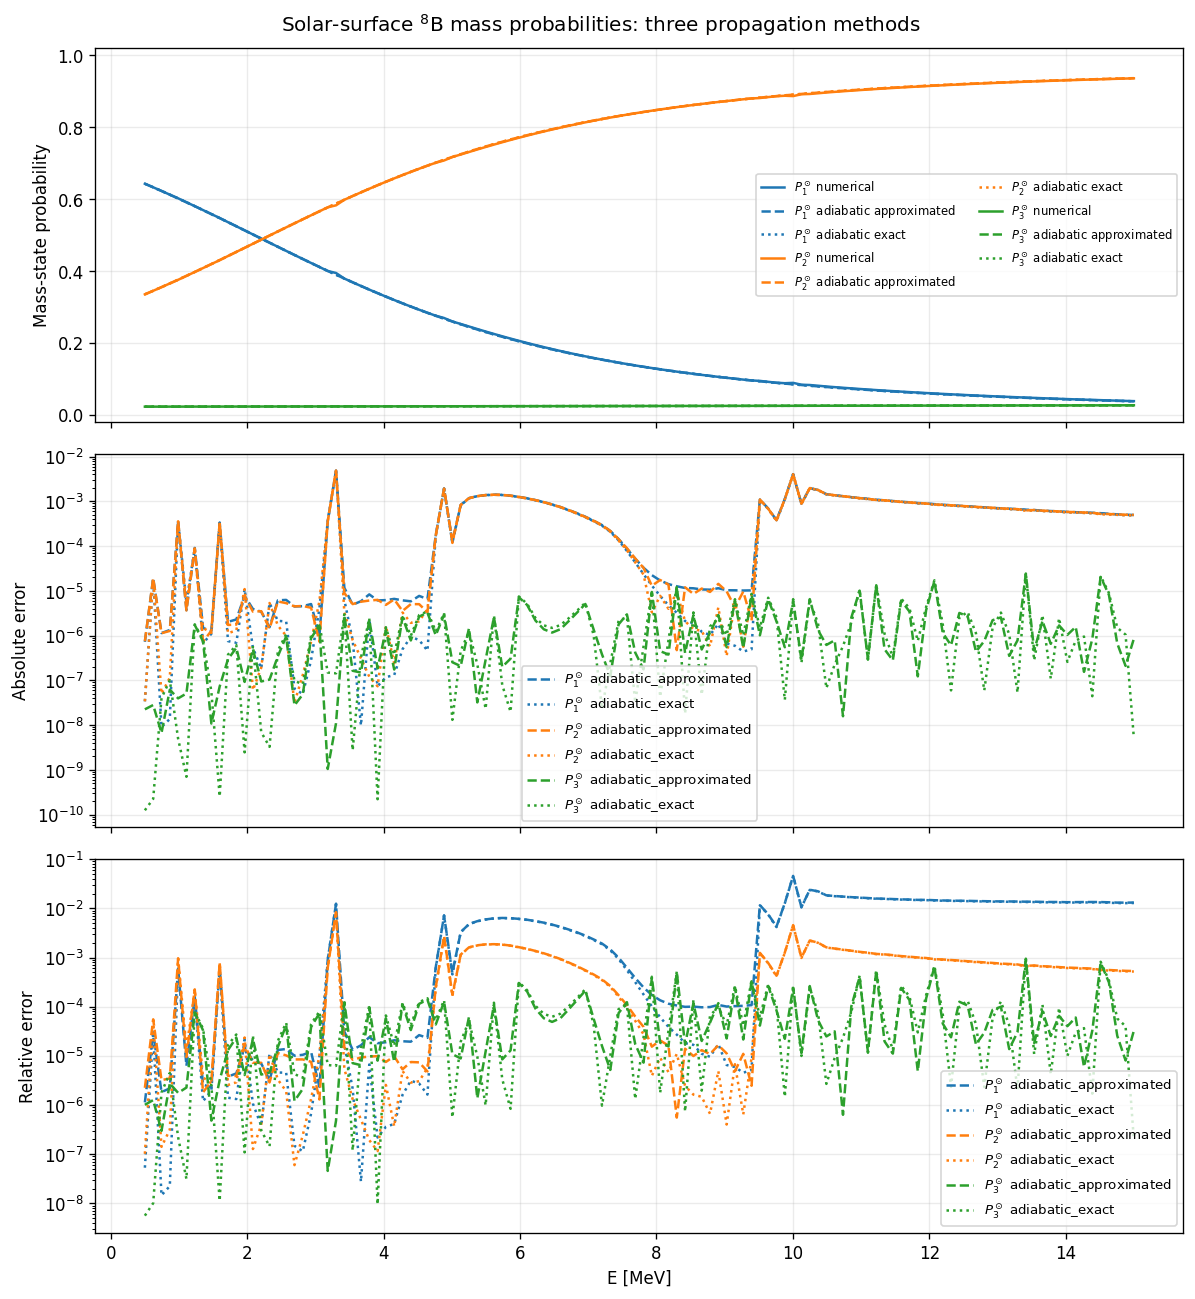

v:\output\validation\intrinsic\intrinsic1_fig3_solar_surface.png


In [5]:
E_solar_surface = torch.linspace(0.5, 15.0, 120, device=context.device, dtype=context.dtype)
solar_surface_reference = solar_probability_mass(oscillation, E_solar_surface, solar, '8B', method='numerical', numerical_sampling='midpoint', legacy_precision=LEGACY_PRECISION)
solar_surface_approximated = solar_probability_mass(oscillation, E_solar_surface, solar, '8B', method='adiabatic_approximated', legacy_precision=LEGACY_PRECISION)
solar_surface_exact = solar_probability_mass(oscillation, E_solar_surface, solar, '8B', method='adiabatic_exact', legacy_precision=LEGACY_PRECISION)
solar_surface_rows = []
solar_surface_errors = {}
for label, tested in [('adiabatic_approximated', solar_surface_approximated), ('adiabatic_exact', solar_surface_exact)]:
    row, absolute, relative = validation_metrics(f'solar surface: {label} vs numerical', solar_surface_reference, tested, reference_label='numerical', tested_label=label, absolute_threshold=ABSOLUTE_THRESHOLD)
    solar_surface_rows.append(row)
    solar_surface_errors[label] = (absolute, relative)
solar_surface_table = pd.DataFrame(solar_surface_rows).set_index('case')
solar_surface_numeric = solar_surface_table.select_dtypes(include='number').columns
display(solar_surface_table.style.format({column: '{:.3e}' for column in solar_surface_numeric}))
fig, axes = plt.subplots(3, 1, figsize=(10, 11), sharex=True)
for mass_index, colour in enumerate(('C0', 'C1', 'C2')):
    label = rf'$P_{{{mass_index + 1}}}^\odot$'
    axes[0].plot(to_numpy(E_solar_surface), to_numpy(solar_surface_reference[:,mass_index]), color=colour, label=f'{label} numerical')
    axes[0].plot(to_numpy(E_solar_surface), to_numpy(solar_surface_approximated[:,mass_index]), '--', color=colour, label=f'{label} adiabatic approximated')
    axes[0].plot(to_numpy(E_solar_surface), to_numpy(solar_surface_exact[:,mass_index]), ':', color=colour, label=f'{label} adiabatic exact')
    for method_label, linestyle in [('adiabatic_approximated', '--'), ('adiabatic_exact', ':')]:
        absolute, relative = solar_surface_errors[method_label]
        axes[1].plot(to_numpy(E_solar_surface), to_numpy(absolute[:,mass_index]), linestyle, color=colour, label=f'{label} {method_label}')
        axes[2].plot(to_numpy(E_solar_surface), to_numpy(relative[:,mass_index]), linestyle, color=colour, label=f'{label} {method_label}')
axes[0].set_ylabel('Mass-state probability'); axes[0].set_ylim(-0.02, 1.02); axes[0].legend(fontsize=7, ncol=2)
axes[1].set_ylabel('Absolute error'); axes[1].set_yscale('log'); axes[1].legend(fontsize=8)
axes[2].set_ylabel('Relative error'); axes[2].set_yscale('log'); axes[2].set_xlabel('E [MeV]'); axes[2].legend(fontsize=8)
for ax in axes: ax.grid(alpha=0.25)
fig.suptitle(r'Solar-surface $^8$B mass probabilities: three propagation methods')
fig.tight_layout()
save_and_show('intrinsic1_fig3_solar_surface.png', fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)

## 4. Pure Flavour States Through Earth

The three coherent pure flavour states propagated independently are

$$|\nu_e\rangle=\begin{pmatrix}1\\0\\0\end{pmatrix},\qquad |\nu_\mu\rangle=\begin{pmatrix}0\\1\\0\end{pmatrix},\qquad |\nu_\tau\rangle=\begin{pmatrix}0\\0\\1\end{pmatrix}.$$

Each vector is propagated coherently through Earth over an energy-nadir grid, testing every initial-flavour column of the transition matrix. The numerical path uses 400 midpoint segments per trajectory. Parallel heatmaps show the maximum absolute and relative discrepancies over initial and final flavours. The additional $3\times2$ grid selects initial $\nu_e$: its left column scans energy near $\eta=0.60$ rad and its right column scans nadir angle near $E=5\,\mathrm{GeV}$. Both branches use `reunitarize=False`.

**Expected results:**

- Both methods conserve total probability.
- The largest differences are expected for long core-crossing paths and around energies where the matter phase is most sensitive to the density approximation.
- The perturbative and numerical curves should follow the same physical oscillation pattern.

,max_abs,mean_abs,max_rel,mean_rel,normalization_numerical,normalization_perturbative,relative_points,absolute_threshold
case,,,,,,,,
pure flavour through Earth,2.460e-02,6.934e-04,6.032e-01,5.137e-03,2.760e-13,2.538e-02,71972,1.000e-03


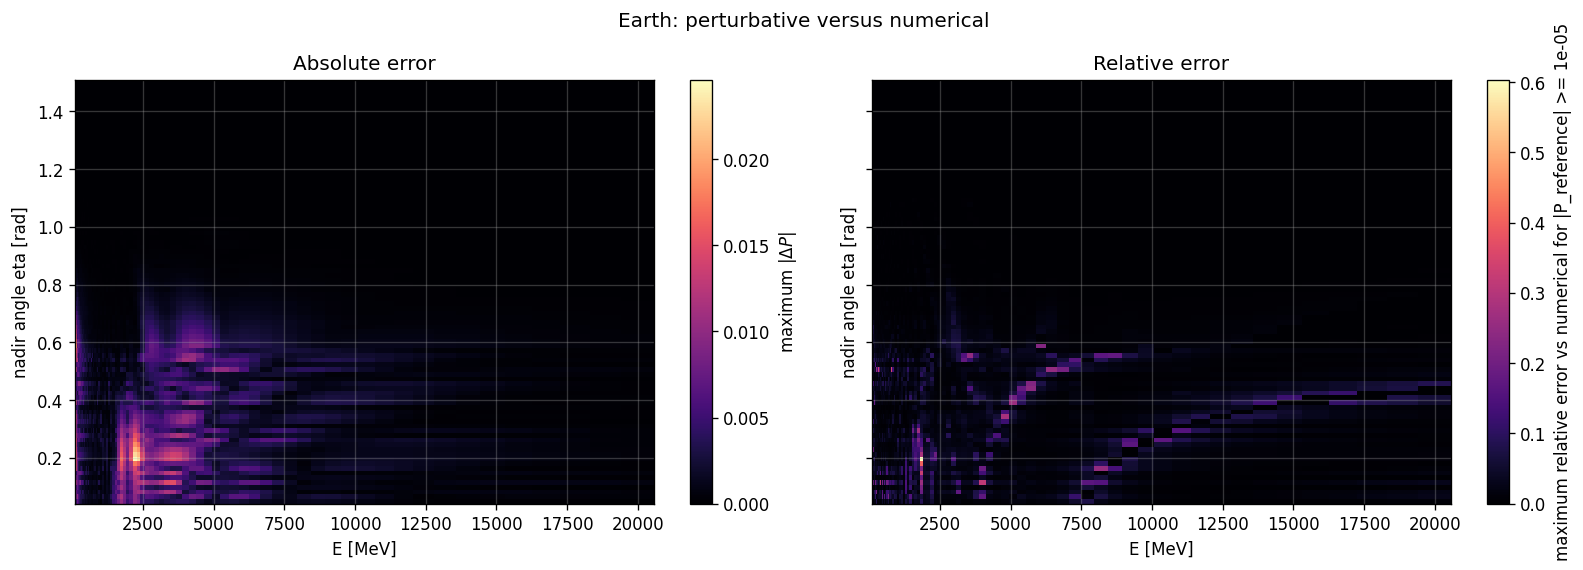

v:\output\validation\intrinsic\intrinsic1_fig4_earth.png


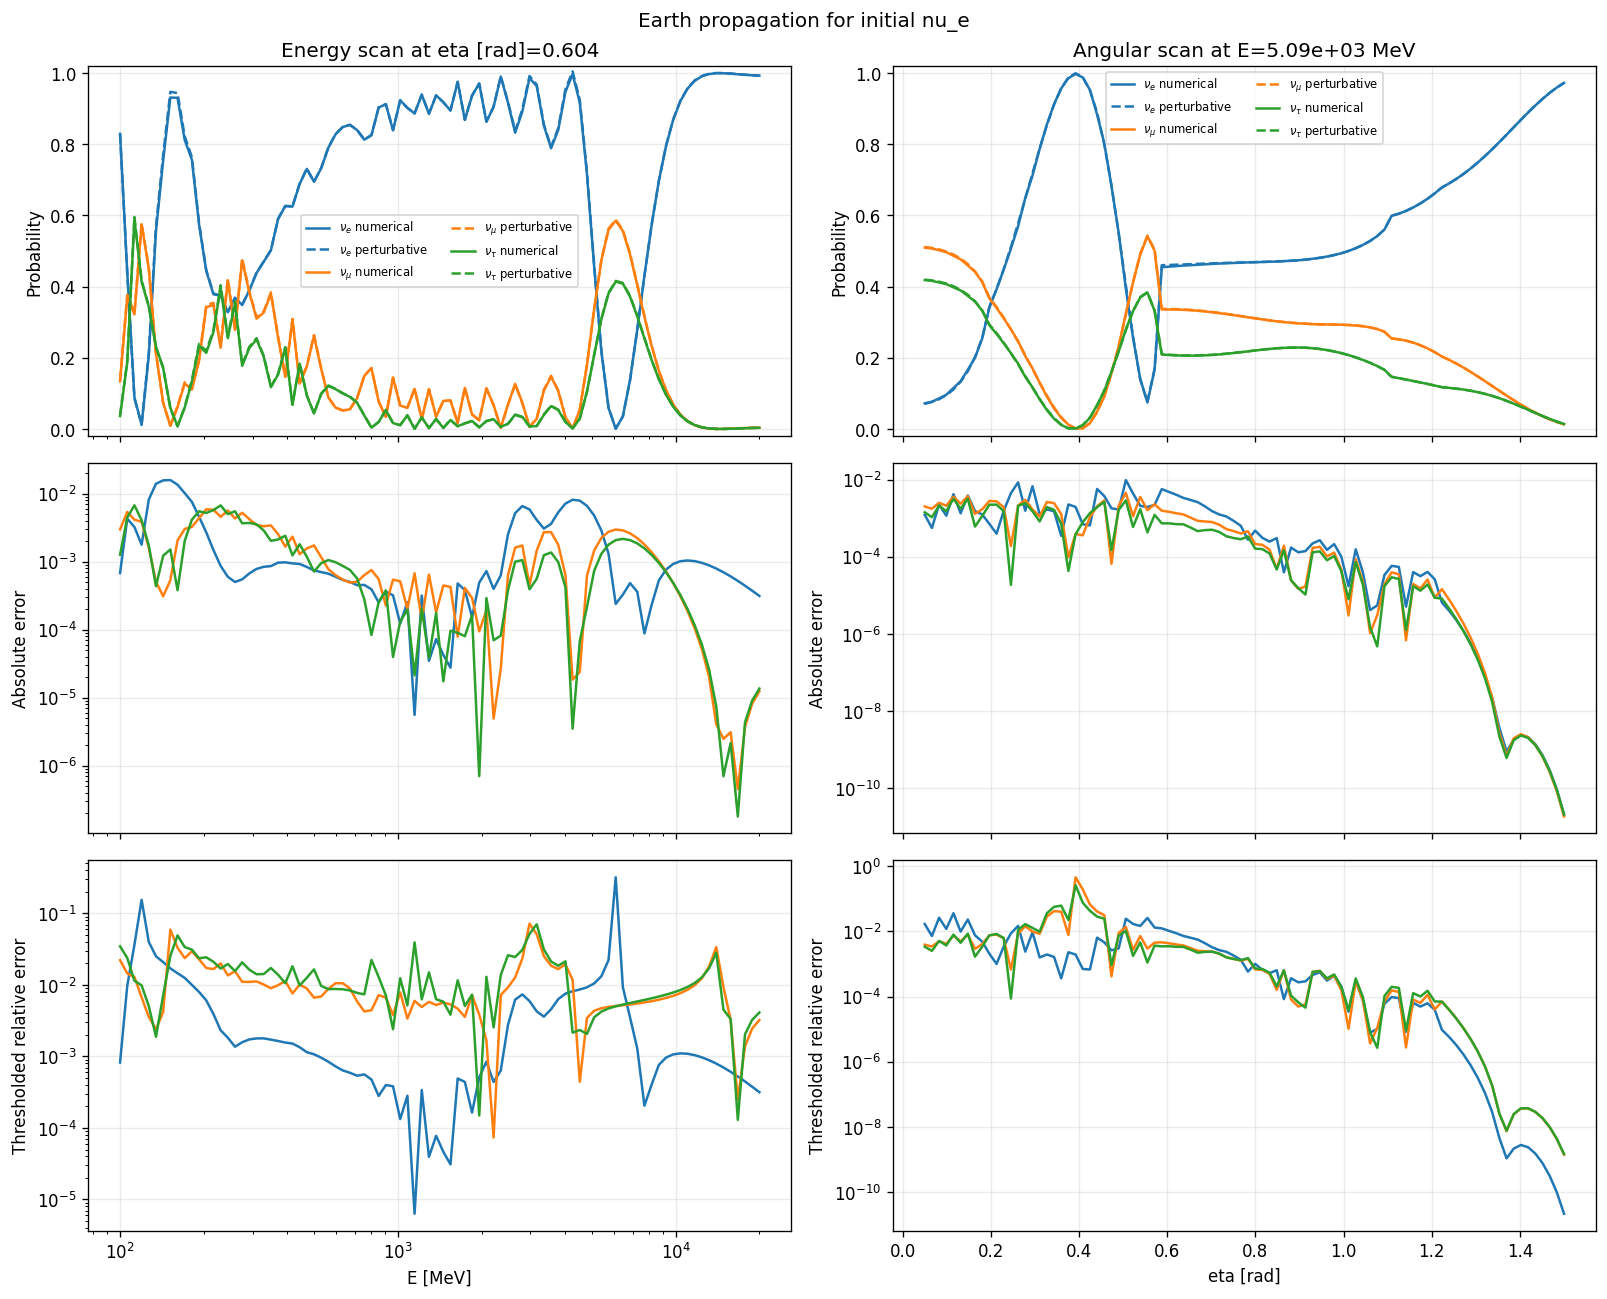

v:\output\validation\intrinsic\intrinsic1_fig4b_earth_slices.png


In [6]:
E_earth = torch.logspace(np.log10(100.0), np.log10(2.0e4), 90, device=context.device, dtype=context.dtype)
eta_earth = torch.linspace(0.05, 1.50, 90, device=context.device, dtype=context.dtype)
def earth_flavour_grid(method):
    per_state = []
    for state in BASIS:
        per_eta = [earth_probability_state(state, earth, oscillation, E_earth[:, None], eta, DEPTH_M, method=method, massbasis=False, nsteps=N_EARTH_STEPS, context=context, reunitarize=False, legacy_precision=LEGACY_PRECISION).reshape(E_earth.numel(), 3) for eta in eta_earth]
        per_state.append(torch.stack(per_eta, dim=1))
    return torch.stack(per_state)
earth_reference = earth_flavour_grid('numerical')
earth_tested = earth_flavour_grid('analytical')
earth_abs, earth_rel = record_metrics('pure flavour through Earth', earth_reference, earth_tested)
validation_heatmap(earth_abs.amax(dim=(0,3)), earth_rel.amax(dim=(0,3)), E_earth, eta_earth, title='Earth: perturbative versus numerical', xlabel='E [MeV]', ylabel='nadir angle eta [rad]', filename='intrinsic1_fig4_earth.png', output_dir=OUTPUT_DIR, reference_label=REFERENCE_LABEL, show_plots=config.show_plots)
validation_comparison_grid(earth_reference[0], earth_tested[0], E_earth, eta_earth, 0.60, 5000.0, title='Earth propagation for initial nu_e', angle_label='eta [rad]', filename='intrinsic1_fig4b_earth_slices.png', output_dir=OUTPUT_DIR, reference_label=REFERENCE_LABEL, tested_label=TESTED_LABEL, log_energy=True, show_plots=config.show_plots)

## 5. Solar Neutrinos to the Detector

Solar $^8$B neutrinos are produced as $\nu_e$ and converted by the adiabatic solar MSW calculation into incoherent mass-eigenstate weights. These common weights are propagated through Earth to the detector; only the Earth method differs between the reference and tested branches. Parallel heatmaps display the maximum errors over final flavour, and the $3\times2$ grid compares the three detected flavours near $\eta=0.55$ rad and $E=10\,\mathrm{MeV}$. Both branches use `reunitarize=False`.

**Expected results:**

- All final-flavour probabilities remain normalized.
- Day-night regeneration is strongest for trajectories with small nadir angle and long Earth chords.
- Perturbative-numerical discrepancies should remain small compared with the physical Earth matter effect.

,max_abs,mean_abs,max_rel,mean_rel,normalization_numerical,normalization_perturbative,relative_points,absolute_threshold
case,,,,,,,,
solar production to detector,8.879e-03,3.077e-04,2.552e-02,9.217e-04,2.994e-11,5.213e-04,24300,1.000e-03


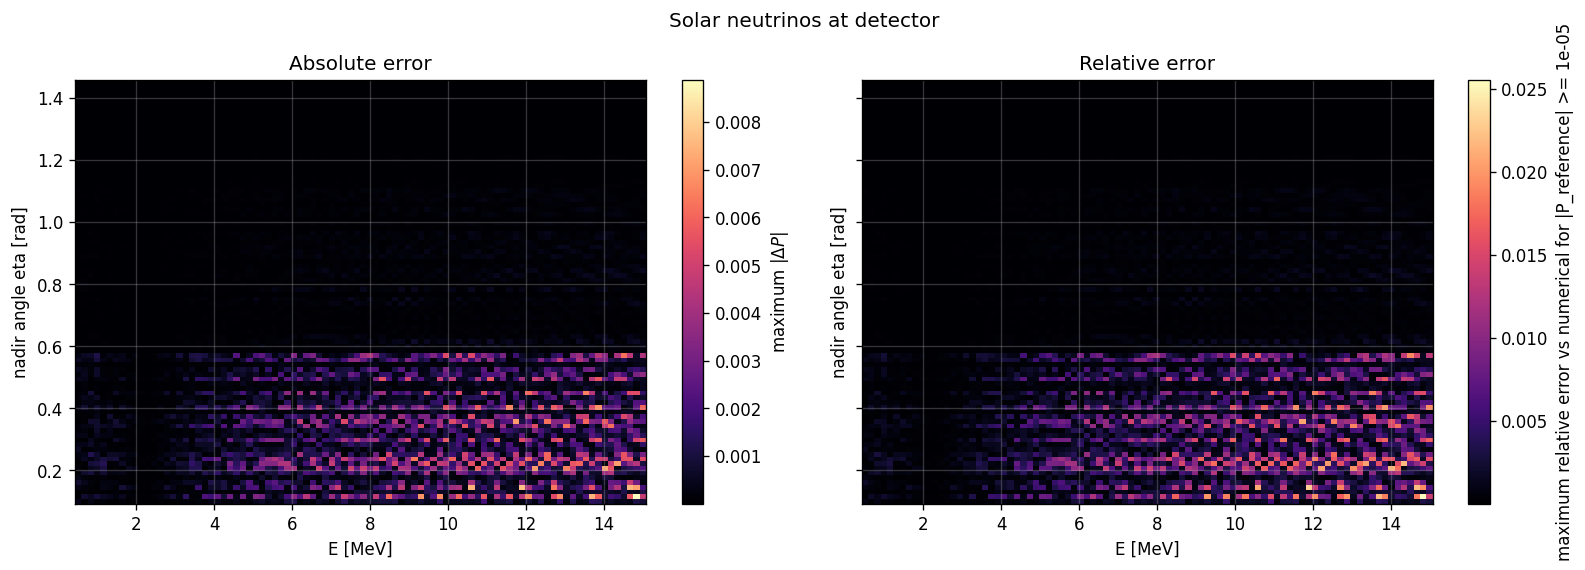

v:\output\validation\intrinsic\intrinsic1_fig5_solar.png


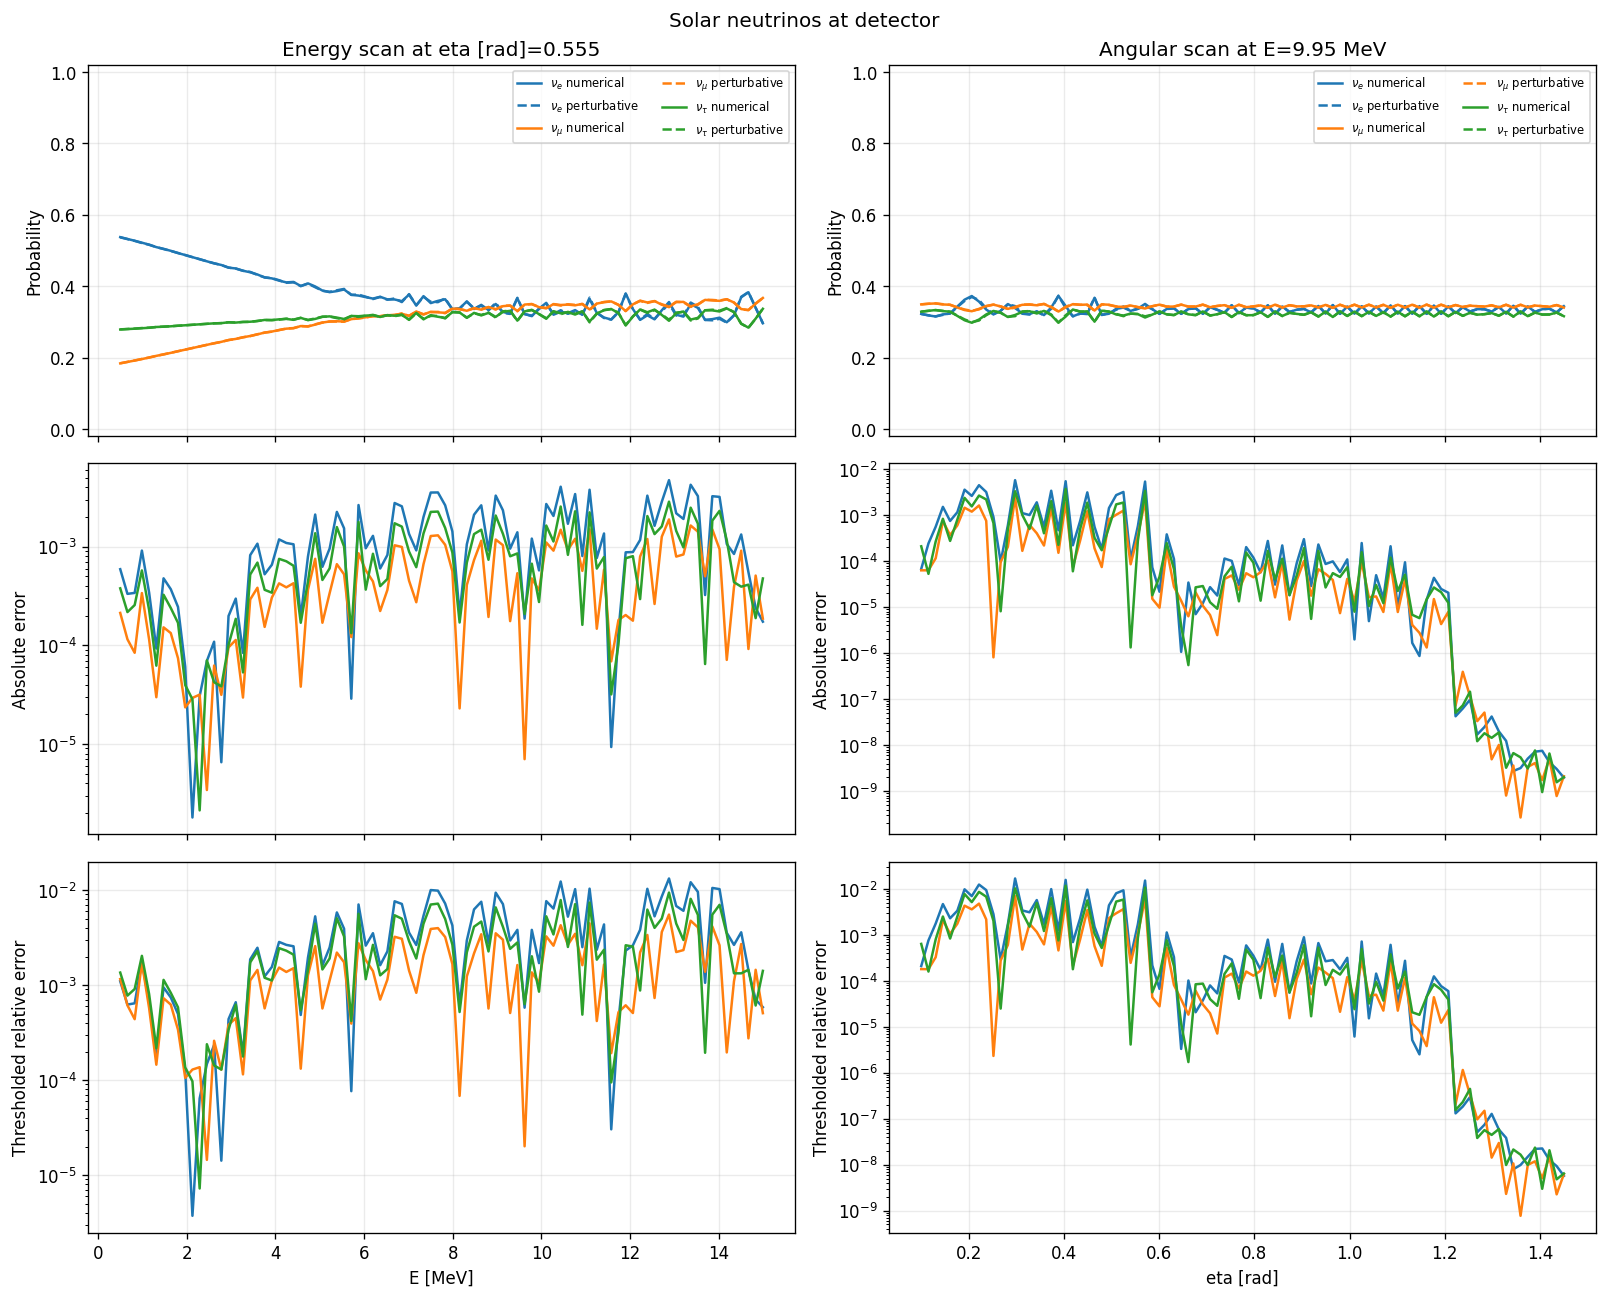

v:\output\validation\intrinsic\intrinsic1_fig5b_solar_slices.png


In [7]:
E_solar = torch.linspace(0.5, 15.0, 90, device=context.device, dtype=context.dtype)
eta_solar = torch.linspace(0.10, 1.45, 90, device=context.device, dtype=context.dtype)
solar_weights = solar_probability_mass(oscillation, E_solar, solar, '8B', legacy_precision=LEGACY_PRECISION)
def solar_detector_grid(method):
    return torch.stack([earth_probability_state(solar_weights, earth, oscillation, E_solar[:,None], eta, DEPTH_M, method=method, massbasis=True, nsteps=N_EARTH_STEPS, context=context, reunitarize=False, legacy_precision=LEGACY_PRECISION).reshape(E_solar.numel(),3) for eta in eta_solar], dim=1)
solar_reference = solar_detector_grid('numerical')
solar_tested = solar_detector_grid('analytical')
solar_abs, solar_rel = record_metrics('solar production to detector', solar_reference, solar_tested)
validation_heatmap(solar_abs.amax(dim=-1), solar_rel.amax(dim=-1), E_solar, eta_solar, title='Solar neutrinos at detector', xlabel='E [MeV]', ylabel='nadir angle eta [rad]', filename='intrinsic1_fig5_solar.png', output_dir=OUTPUT_DIR, reference_label=REFERENCE_LABEL, show_plots=config.show_plots)
validation_comparison_grid(solar_reference, solar_tested, E_solar, eta_solar, 0.55, 10.0, title='Solar neutrinos at detector', angle_label='eta [rad]', filename='intrinsic1_fig5b_solar_slices.png', output_dir=OUTPUT_DIR, reference_label=REFERENCE_LABEL, tested_label=TESTED_LABEL, show_plots=config.show_plots)

## 6. Atmospheric Propagation

### 6.1 Atmospheric neutrinos to the surface

The complete coherent $3\times3$ flavour-transition matrix is compared at the Earth surface. The perturbative atmosphere uses six cubic local fits and the numerical reference uses 600 midpoint density segments. Both plotted errors are maximized over the complete transition matrix. The $3\times2$ grid selects initial $\nu_e$ and shows energy dependence near the horizon ($\theta=89^\circ$) and angular dependence near $E=10\,\mathrm{GeV}$.

**Expected results:**

- Agreement should be especially strong because atmospheric electron density is low.
- Differences may grow near the horizon, where the atmospheric path is longest.
- Every transition-matrix column should sum to one.

,max_abs,mean_abs,max_rel,mean_rel,normalization_numerical,normalization_perturbative,relative_points,absolute_threshold
case,,,,,,,,
atmosphere production to surface,1.507e-11,1.551e-13,1.245e-09,3.814e-12,6.553e-13,7.438e-14,43876,1.000e-03


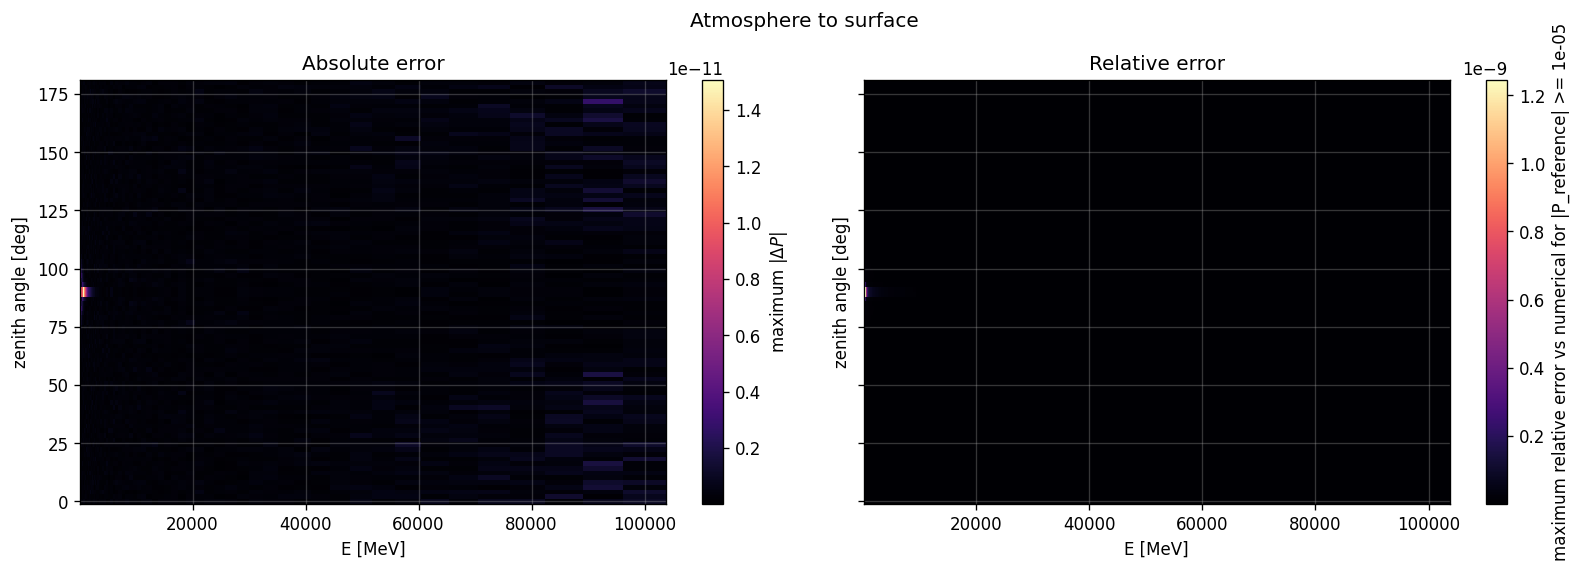

v:\output\validation\intrinsic\intrinsic1_fig61_surface.png


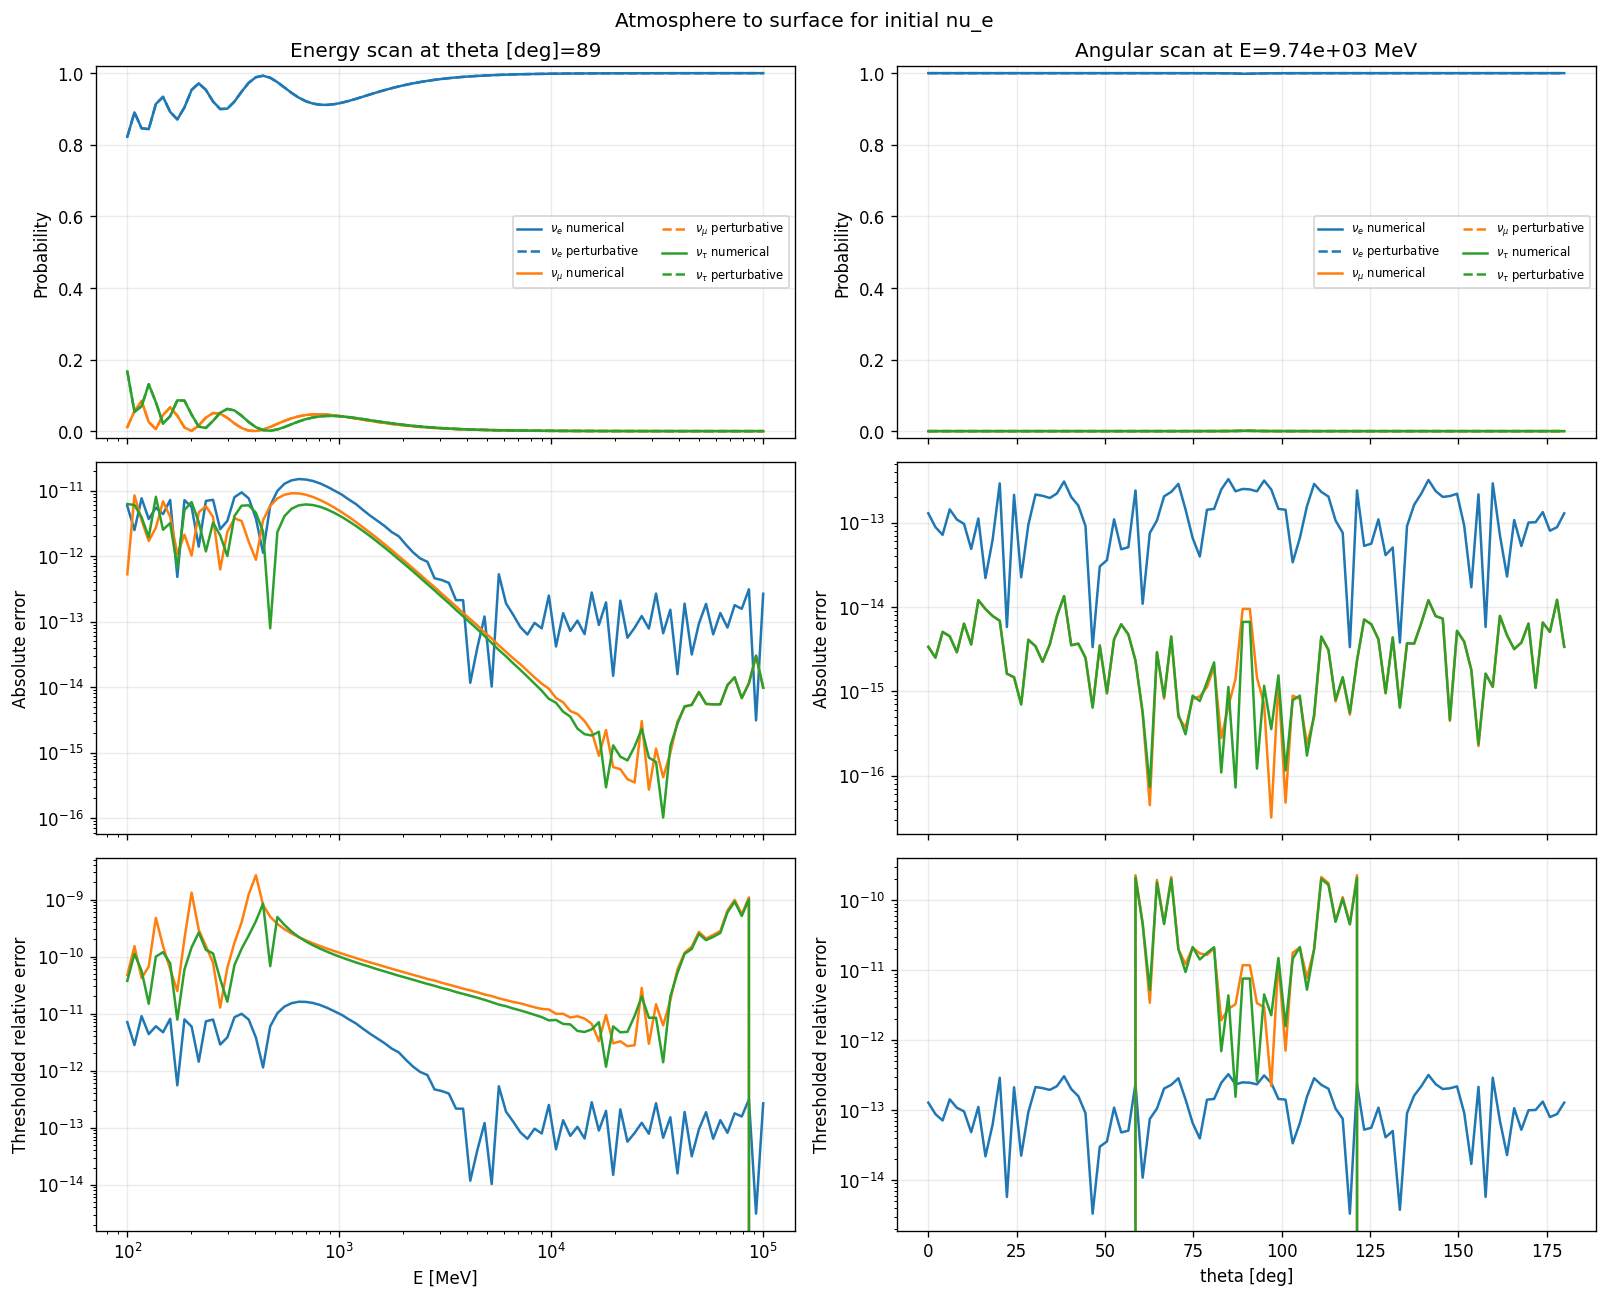

v:\output\validation\intrinsic\intrinsic1_fig61b_surface_slices.png


In [8]:
E_atm = torch.logspace(2.0, 5.0, 90, device=context.device, dtype=context.dtype)
theta_atm = torch.linspace(0.0, 180.0, 90, device=context.device, dtype=context.dtype)
atm_args = dict(oscillation=oscillation, E_MeV=E_atm[:,None], h_km=25.0, theta_deg=theta_atm[None,:], depth_km=DEPTH_M/1000.0, atmosphere=atmosphere, context=context, legacy_precision=LEGACY_PRECISION)
surface_reference = atmosphere_probability_transition(**atm_args, method='numerical')
surface_tested = atmosphere_probability_transition(**atm_args, method='analytical')
surface_abs, surface_rel = record_metrics('atmosphere production to surface', surface_reference, surface_tested)
validation_heatmap(surface_abs.amax(dim=(-2,-1)), surface_rel.amax(dim=(-2,-1)), E_atm, theta_atm, title='Atmosphere to surface', xlabel='E [MeV]', ylabel='zenith angle [deg]', filename='intrinsic1_fig61_surface.png', output_dir=OUTPUT_DIR, reference_label=REFERENCE_LABEL, show_plots=config.show_plots)
validation_comparison_grid(surface_reference[..., :,0], surface_tested[..., :,0], E_atm, theta_atm, 89.0, 1e4, title='Atmosphere to surface for initial nu_e', angle_label='theta [deg]', filename='intrinsic1_fig61b_surface_slices.png', output_dir=OUTPUT_DIR, reference_label=REFERENCE_LABEL, tested_label=TESTED_LABEL, log_energy=True, show_plots=config.show_plots)

### 6.2 Atmospheric neutrinos to the underground detector

Atmosphere amplitudes act on each pure state first; the resulting coherent surface state is then propagated through Earth. The total probability is therefore not constructed by multiplying probability matrices. Parallel heatmaps summarize the maximum errors. The $3\times2$ grid selects initial $\nu_e$, an up-going trajectory at $\theta=150^\circ$, and an angular scan near $E=5\,\mathrm{GeV}$. Both basic branches use `reunitarize=False`.

**Expected results:**

- Down-going events mainly test atmospheric propagation, whereas up-going events also test long Earth chords.
- Combined probabilities must remain normalized.
- The largest discrepancies are expected for up-going, matter-sensitive trajectories; this is the strongest end-to-end test because coherence is retained at the surface.

,max_abs,mean_abs,max_rel,mean_rel,normalization_numerical,normalization_perturbative,relative_points,absolute_threshold
case,,,,,,,,
atmosphere production to detector,2.430e-02,3.888e-04,3.864e-01,3.413e-03,8.686e-13,2.427e-02,63002,1.000e-03


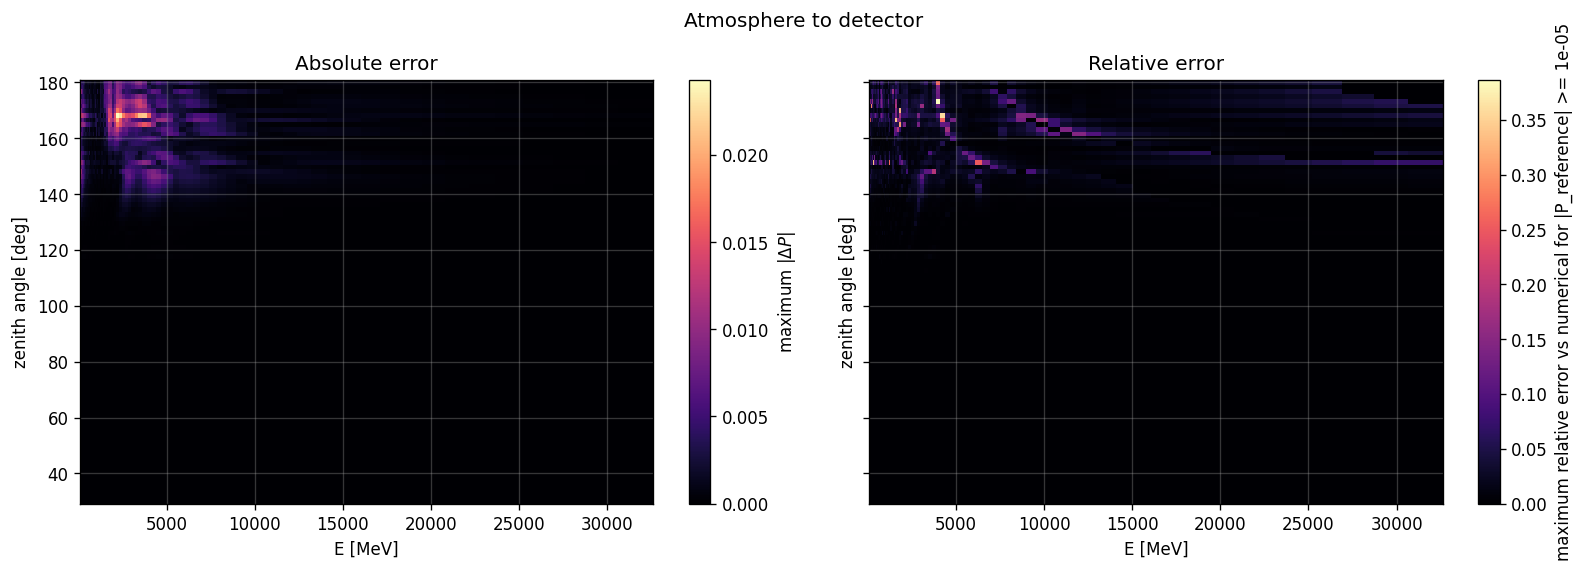

v:\output\validation\intrinsic\intrinsic1_fig62_detector.png


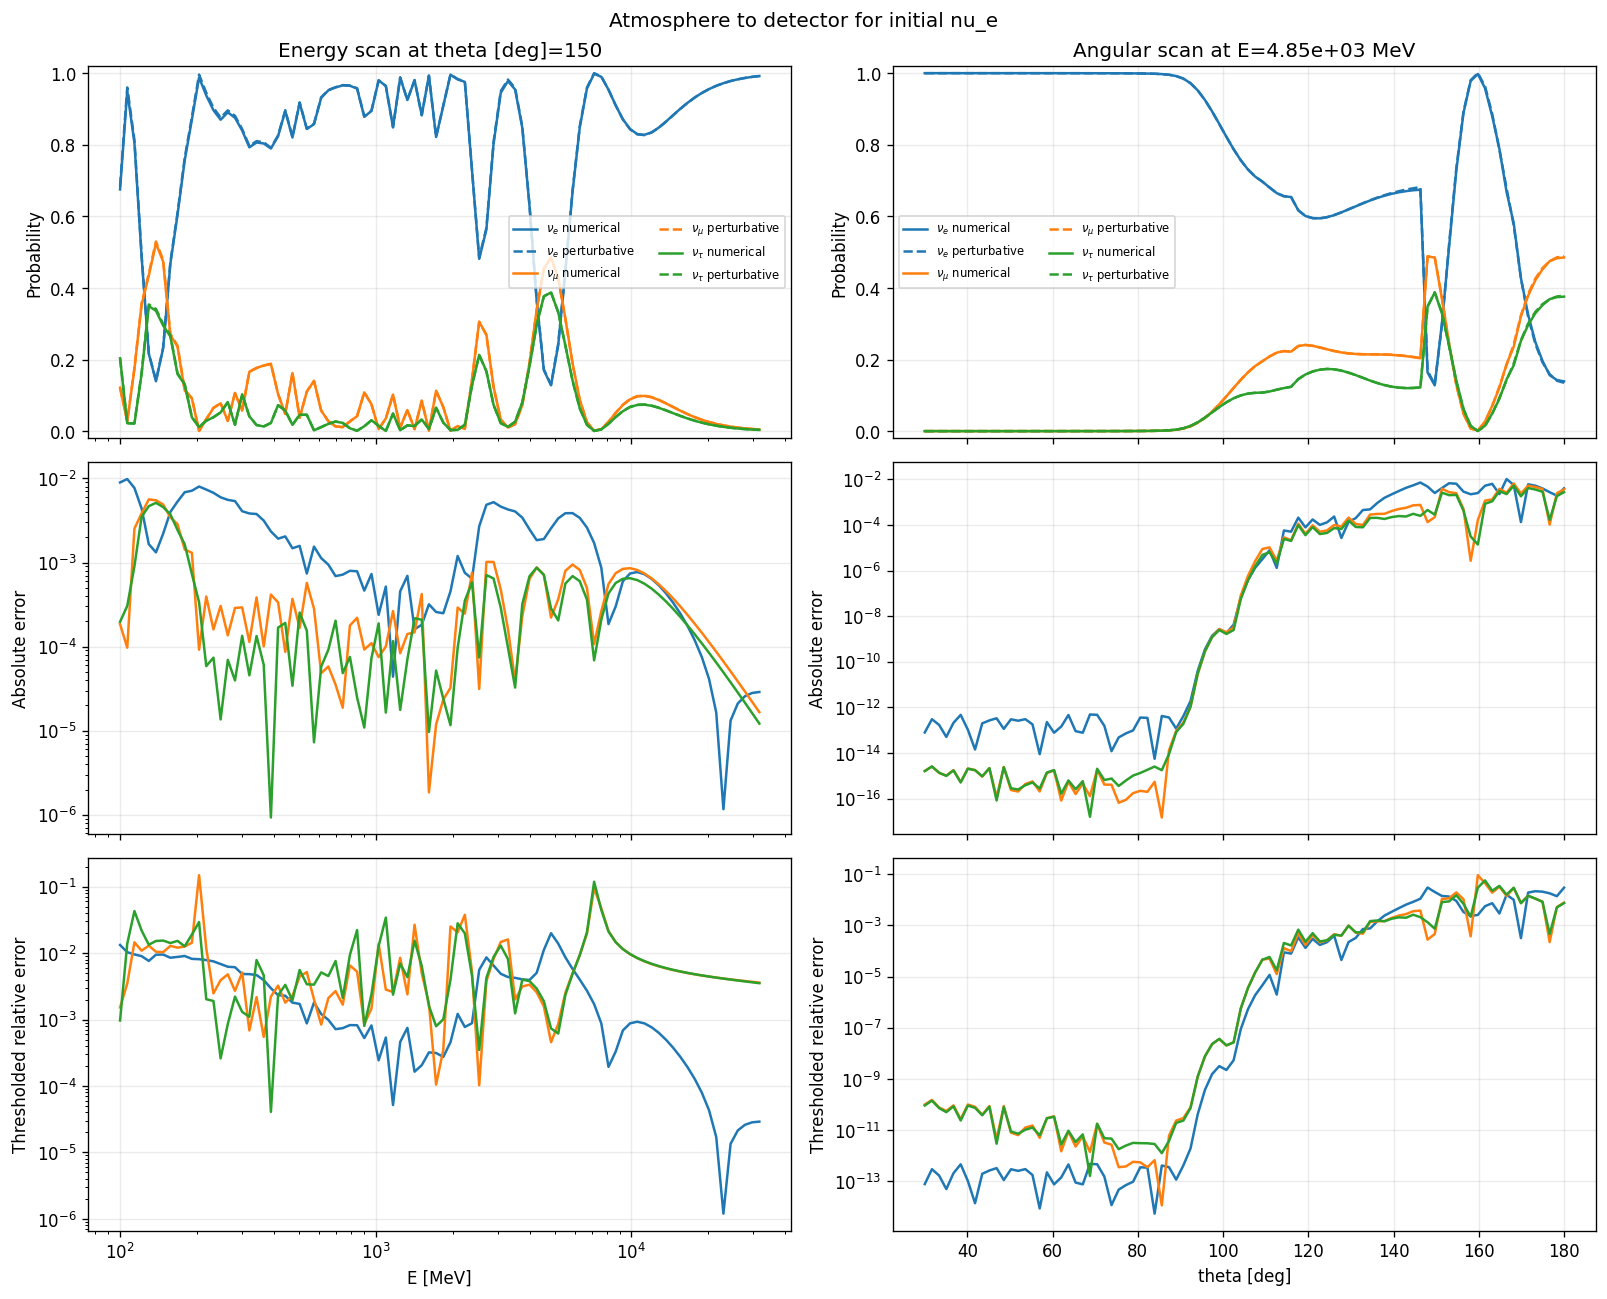

v:\output\validation\intrinsic\intrinsic1_fig62b_detector_slices.png


In [9]:
E_det = torch.logspace(2.0, 4.5, 90, device=context.device, dtype=context.dtype)
theta_det = torch.linspace(30.0, 180.0, 90, device=context.device, dtype=context.dtype)
def atmosphere_detector_grid(method):
    S_atm, _ = atmosphere_evolutor(oscillation, E_det[:,None], 25.0, theta_det[None,:], DEPTH_M/1000.0, atmosphere=atmosphere, context=context, method=method, legacy_precision=LEGACY_PRECISION)
    angle_results = []
    for i_theta, theta in enumerate(theta_det):
        eta = torch.pi - torch.deg2rad(theta)
        states = []
        for state in BASIS:
            surface_state = torch.matmul(S_atm[:,i_theta], state)
            states.append(earth_probability_state(surface_state, earth, oscillation, E_det[:,None], eta, DEPTH_M, method=method, massbasis=False, nsteps=N_EARTH_STEPS, context=context, reunitarize=False, legacy_precision=LEGACY_PRECISION).reshape(E_det.numel(),3))
        angle_results.append(torch.stack(states))
    return torch.stack(angle_results, dim=2)
detector_reference = atmosphere_detector_grid('numerical')
detector_tested = atmosphere_detector_grid('analytical')
detector_abs, detector_rel = record_metrics('atmosphere production to detector', detector_reference, detector_tested)
validation_heatmap(detector_abs.amax(dim=(0,3)), detector_rel.amax(dim=(0,3)), E_det, theta_det, title='Atmosphere to detector', xlabel='E [MeV]', ylabel='zenith angle [deg]', filename='intrinsic1_fig62_detector.png', output_dir=OUTPUT_DIR, reference_label=REFERENCE_LABEL, show_plots=config.show_plots)
validation_comparison_grid(detector_reference[0], detector_tested[0], E_det, theta_det, 150.0, 5000.0, title='Atmosphere to detector for initial nu_e', angle_label='theta [deg]', filename='intrinsic1_fig62b_detector_slices.png', output_dir=OUTPUT_DIR, reference_label=REFERENCE_LABEL, tested_label=TESTED_LABEL, log_energy=True, show_plots=config.show_plots)

## 7. Summary
The summary contains the four end-to-end physical comparisons accumulated in this notebook: pure-flavour Earth propagation, solar neutrinos at the detector, atmospheric propagation to the surface and atmosphere-plus-Earth propagation to the underground detector. Solar-surface and Standard-Model-limit diagnostics remain separate because they compare different approximations or physical models.

The table and $2\times2$ chart report maximum and mean absolute and thresholded-relative errors. Probability-normalization diagnostics remain available in the table.

**Expected results:** every metric must be finite, normalization errors must remain small and the numerical and tested methods must reproduce the same Standard Model oscillation patterns.


,max_abs,mean_abs,max_rel,mean_rel,normalization_numerical,normalization_perturbative,relative_points,absolute_threshold
case,,,,,,,,
pure flavour through Earth,2.460e-02,6.934e-04,6.032e-01,5.137e-03,2.760e-13,2.538e-02,7.197e+04,1.000e-03
solar production to detector,8.879e-03,3.077e-04,2.552e-02,9.217e-04,2.994e-11,5.213e-04,2.430e+04,1.000e-03
atmosphere production to surface,1.507e-11,1.551e-13,1.245e-09,3.814e-12,6.553e-13,7.438e-14,4.388e+04,1.000e-03
atmosphere production to detector,2.430e-02,3.888e-04,3.864e-01,3.413e-03,8.686e-13,2.427e-02,6.300e+04,1.000e-03


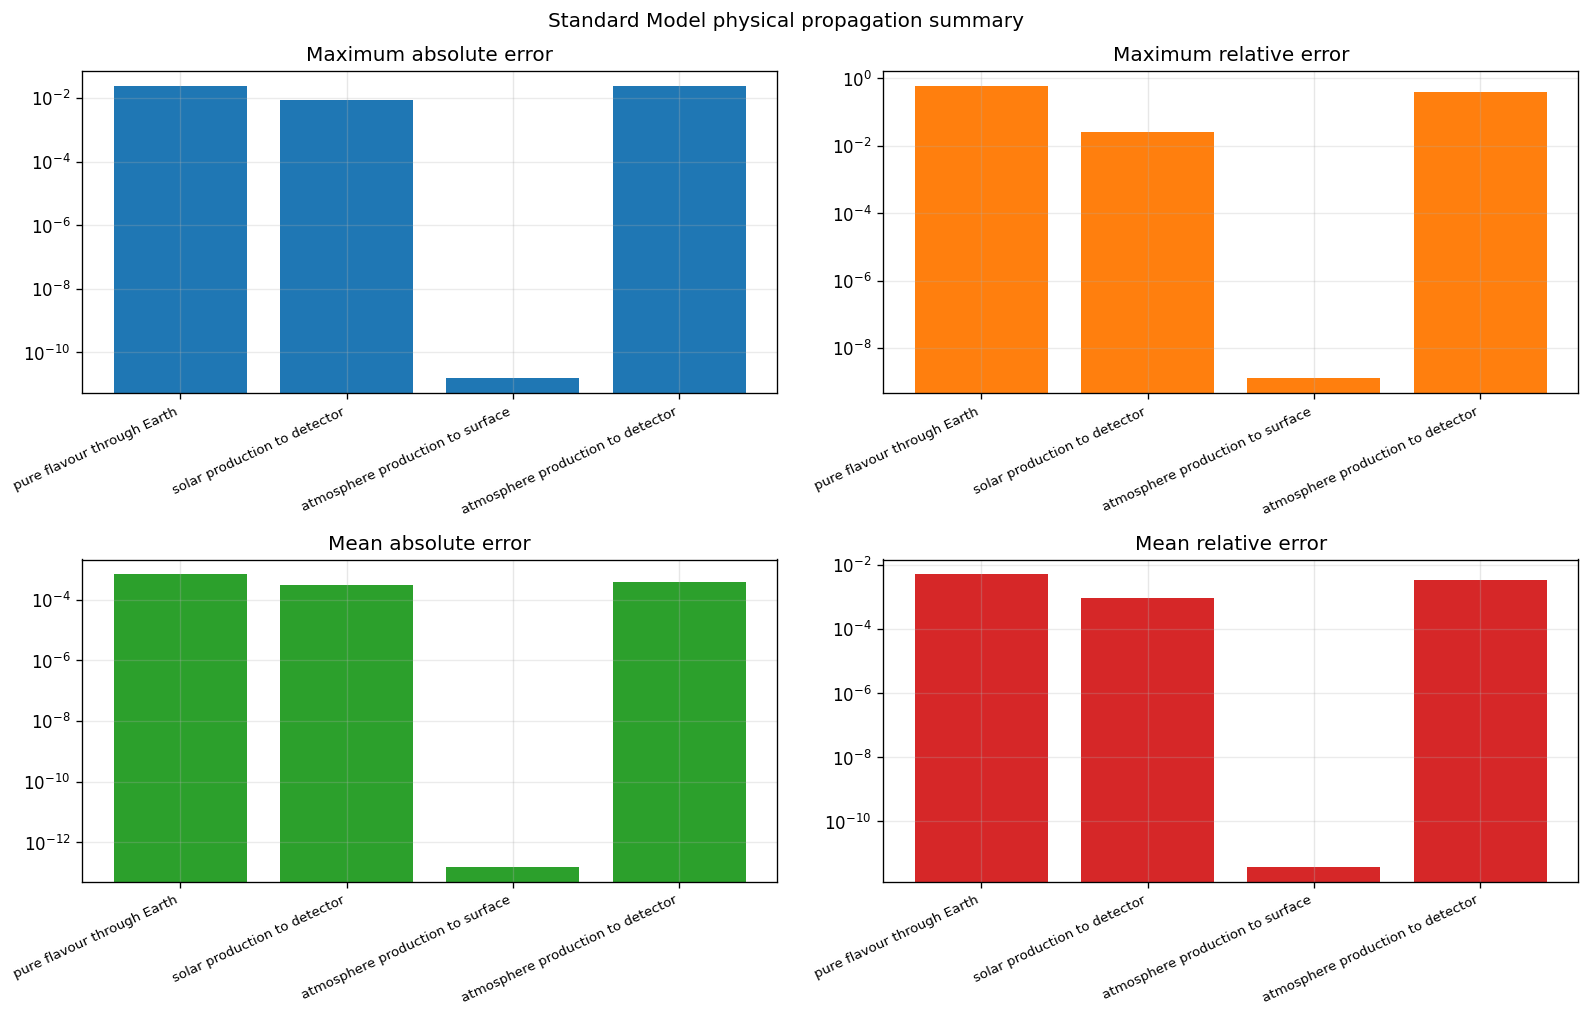

v:\output\validation\intrinsic\intrinsic1_fig7_summary.png
All four physical comparisons completed successfully.


In [10]:
summary = pd.DataFrame(summaries).set_index('case')
display(summary.style.format({column: '{:.3e}' for column in summary.select_dtypes(include='number').columns}))
summary.to_csv(OUTPUT_DIR / 'validation_intrinsic1_summary.csv')
validation_summary_plot(summaries, title='Standard Model physical propagation summary', filename='intrinsic1_fig7_summary.png', output_dir=OUTPUT_DIR, show_plots=config.show_plots)
assert np.isfinite(summary[['max_abs','mean_abs','max_rel','mean_rel']].to_numpy()).all()
print('All four physical comparisons completed successfully.')
